In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('synthetic_clinic_patients_englishnames_hidden.csv')

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['VisitCost'] = df['VisitCost'].fillna(df['VisitCost'].mean())

categorical_cols = ['Gender', 'Diagnosis', 'Treatment', 'VisitType', 'Doctor', 'FollowUpRequired']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop(['PatientID', 'VisitCost'], axis=1)
y = df['VisitCost']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df


,PatientID,Age,Gender,Diagnosis,Treatment,VisitType,Doctor,VisitCost,FollowUpRequired
0,P0001,53.000000,0,1,0,0,0,811.940000,0
1,P0002,41.000000,0,2,3,0,1,789.700000,0
2,P0003,46.894737,1,0,4,1,0,1412.300000,0
3,P0004,31.000000,0,1,1,0,0,1087.288544,0
4,P0005,69.000000,1,2,1,1,0,1862.260000,0
...,...,...,...,...,...,...,...,...,...
195,P0196,87.000000,1,2,0,1,4,1087.288544,0
196,P0197,77.000000,1,3,1,1,1,811.820000,1
197,P0198,12.000000,0,2,0,1,2,1659.000000,0
198,P0199,9.000000,0,2,3,1,0,1087.288544,1


In [8]:
models = {"Linear": LinearRegression(), "Ridge": Ridge(alpha=1.0), "Lasso": Lasso(alpha=0.1)}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"Model: {name} | RMSE: {rmse}")

Model: Linear | RMSE: 520.1937728305007
Model: Ridge | RMSE: 519.9300697320516
Model: Lasso | RMSE: 520.1668368117463


In [4]:
clustering_data = df.drop('PatientID', axis=1)
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(clustering_data)
    inertia.append(km.inertia_)

optimal_k = 3
km_final = KMeans(n_clusters=optimal_k, random_state=42)
df['Cluster'] = km_final.fit_predict(clustering_data)


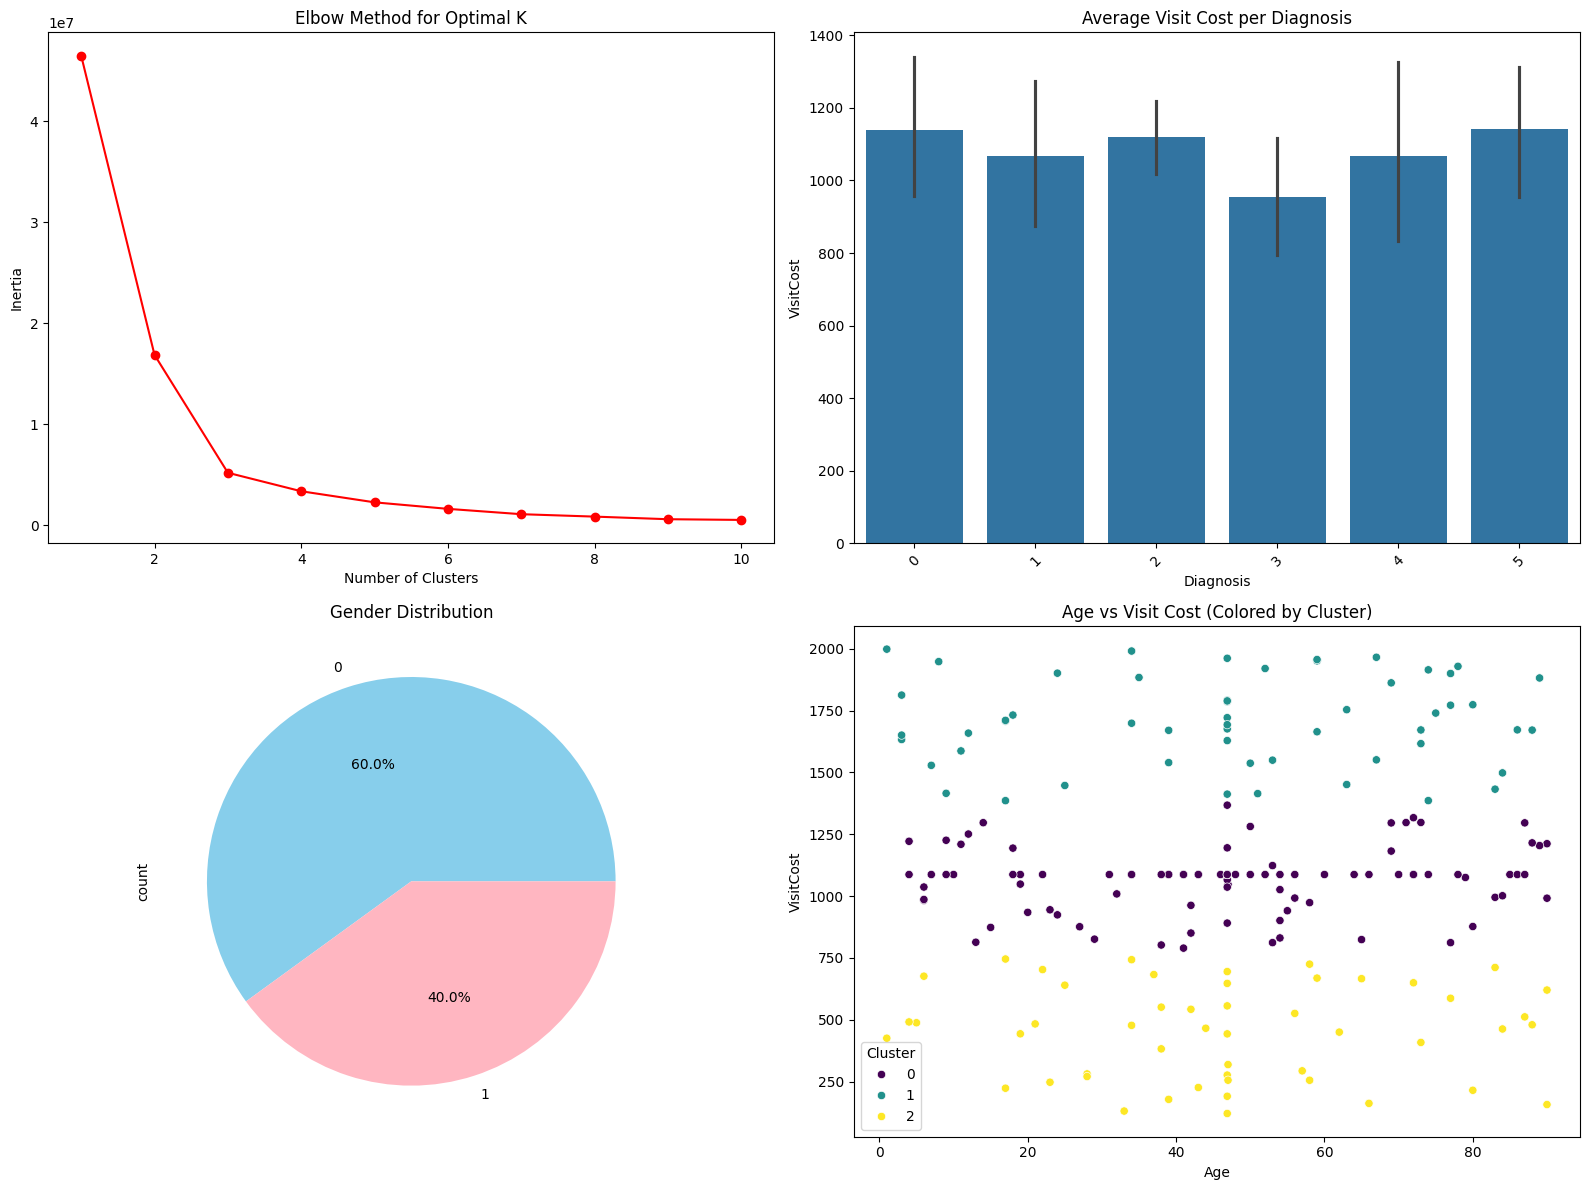

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(K_range, inertia, 'ro-')
axes[0, 0].set_title('Elbow Method for Optimal K')
axes[0, 0].set_xlabel('Number of Clusters')
axes[0, 0].set_ylabel('Inertia')

sns.barplot(x='Diagnosis', y='VisitCost', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Average Visit Cost per Diagnosis')
axes[0, 1].tick_params(axis='x', rotation=45)

df['Gender'].value_counts().plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%', colors=['skyblue', 'lightpink'])
axes[1, 0].set_title('Gender Distribution')

sns.scatterplot(x='Age', y='VisitCost', hue='Cluster', data=df, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Age vs Visit Cost (Colored by Cluster)')

plt.tight_layout()
plt.show()